# Chapter 22: Symplectic Manifolds

**Source Span.** `Introduction to Smooth Manifolds.pdf`, Chapter 22, printed pages `564-595` (PDF extraction window inspected: approximately `pdftotext -f 582 -l 613`).

**Chapter goal.** Build a computational model for the chapter's main claim: a symplectic form is locally algebraically rigid but globally and dynamically rich. The notebook follows the route from nondegenerate alternating tensors, through cotangent bundles and Darboux-Moser normalization, to Hamiltonian dynamics, Poisson brackets, contact/jet geometry, and first-order PDE flowouts.

The source pages were used only for structure, terminology, theorem orientation, and examples to cover. The prose, code, diagrams, artifact names, and checks below are original teaching material.


## Refreshed Visual Storyboard

1. **Proof-route dependency map.** Track which algebraic facts feed Darboux, Hamiltonian mechanics, contact geometry, and PDE flowouts.
2. **Canonical tensor matrix.** View a symplectic tensor as a skew matrix whose determinant and top wedge coefficient witness nondegeneracy.
3. **Complement classifier.** Compute symplectic complements for representative subspaces and classify symplectic, isotropic, coisotropic, and Lagrangian behavior by rank and containment tests.
4. **Cotangent graph lab.** Compare a closed 1-form graph with a nonclosed graph inside `T*R^2`; the pullback of the canonical form is the visible residual.
5. **Darboux-Moser field.** Use a radial Moser correction field to see how a nonconstant area coefficient is flattened locally.
6. **Hamiltonian and Poisson lab.** Plot oscillator trajectories, then check energy conservation and Poisson commutation symbolically.
7. **Jet/PDE flowout.** Show a Hamilton-Jacobi flowout and verify the corresponding 1-jet is Legendrian for the canonical contact form.

## Computational Translation Guide and Library Routing

| Chapter object | Computational object | Inspection target |
| --- | --- | --- |
| Symplectic tensor | Skew matrix `J`, determinant, wedge coefficient | Nondegeneracy is an invertible pairing, not a length measurement |
| Symplectic complement | Nullspace of `B.T @ J` for a basis matrix `B` | Dimensions add to `dim V`; containment determines subspace type |
| Tautological 1-form on `T*M` | Coordinates `(x, y, p, q)` with `theta = p dx + q dy` | Pulling back `omega = -d theta` to a graph detects whether the 1-form is closed |
| Darboux theorem | Moser path `omega_t` and time-dependent vector field `V_t` | The residual `d(i_V omega_t) + d/dt omega_t` vanishes |
| Hamiltonian vector field | `X_H = H_p d/dq - H_q d/dp` | Trajectories stay on level sets; Poisson brackets detect conserved quantities |
| Contact and jet geometry | `eta = dz - p dx - q dy` on `J^1 R^2` | A 1-jet section is Legendrian exactly when `eta` pulls back to zero |


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from IPython.display import Markdown, display


def locate_book_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "Introduction to Smooth Manifolds.pdf").exists()
            and (candidate / "source_map.json").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
        nested = candidate / "Introduction-to-Smooth-Manifolds"
        if (
            (nested / "Introduction to Smooth Manifolds.pdf").exists()
            and (nested / "source_map.json").exists()
            and (nested / "utils").exists()
        ):
            return nested
    raise RuntimeError("Could not locate the Introduction-to-Smooth-Manifolds root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    ensure_parent,
    save_csv,
    save_json,
    save_matplotlib,
)


UNIT_KEY = "chapter-22-symplectic-manifolds"
UNIT_TITLE = "Symplectic Manifolds"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

generated_artifacts: list[Path] = []


def register(path: Path) -> Path:
    path = Path(path)
    if path not in generated_artifacts:
        generated_artifacts.append(path)
    return path


def save_plotly_standalone(fig: go.Figure, path: Path) -> Path:
    path = ensure_parent(path)
    fig.write_html(str(path), include_plotlyjs=True, full_html=True)
    return register(path)


routing_rows = [
    {
        "concept": "symplectic tensor and top wedge",
        "representation": "skew matrix heatmap plus exact determinant",
        "library": "SymPy + Matplotlib",
        "why": "exact algebra checks nondegeneracy; static matrix is the clearest visual",
    },
    {
        "concept": "symplectic complements and subspace types",
        "representation": "nullspaces, rank table, containment diagram",
        "library": "SymPy + Matplotlib",
        "why": "classification is finite-dimensional linear algebra with exact ranks",
    },
    {
        "concept": "canonical cotangent form and Lagrangian graphs",
        "representation": "projected graphs of 1-forms with residual checks",
        "library": "Plotly + SymPy",
        "why": "the graph lives in four dimensions; interactive 3D projection exposes the missing coordinate",
    },
    {
        "concept": "Darboux-Moser deformation",
        "representation": "time-dependent correction vector field",
        "library": "SymPy + Matplotlib",
        "why": "the proof hinges on an exact differential identity and a readable local field",
    },
    {
        "concept": "Hamiltonian vector fields and Poisson brackets",
        "representation": "phase portraits and symbolic brackets",
        "library": "Plotly + SymPy",
        "why": "flows are geometric while Poisson conservation is algebraic",
    },
    {
        "concept": "contact/jet geometry and PDE flowouts",
        "representation": "solution surface with characteristic curves and contact residuals",
        "library": "Plotly + SymPy",
        "why": "the jet contact condition and PDE residual can be checked directly",
    },
]
routing_path = register(save_csv(routing_rows, TABLES / "library-routing.csv"))
display(Markdown(f"Book root: `{BOOK_ROOT.name}`. Artifact root: `{ARTIFACT_ROOT.relative_to(BOOK_ROOT)}`."))
display(Markdown(f"Library routing saved to `{routing_path.relative_to(BOOK_ROOT)}`."))


Book root: `Introduction-to-Smooth-Manifolds`. Artifact root: `artifacts\chapter-22-symplectic-manifolds`.

Library routing saved to `artifacts\chapter-22-symplectic-manifolds\tables\library-routing.csv`.

## Proof Route Through the Chapter

The chapter does not merely introduce a new tensor. It shows how a closed, nondegenerate 2-form turns three older ideas into a single machine:

- multilinear algebra supplies the nondegenerate alternating pairing;
- exterior calculus supplies closedness, pullback, exactness, and Moser's deformation identity;
- flow theory turns Hamiltonian vector fields into geometric constructions.

The directed graph below is a reading map: every edge says that the upstream object is needed to make the downstream construction checkable in this notebook.


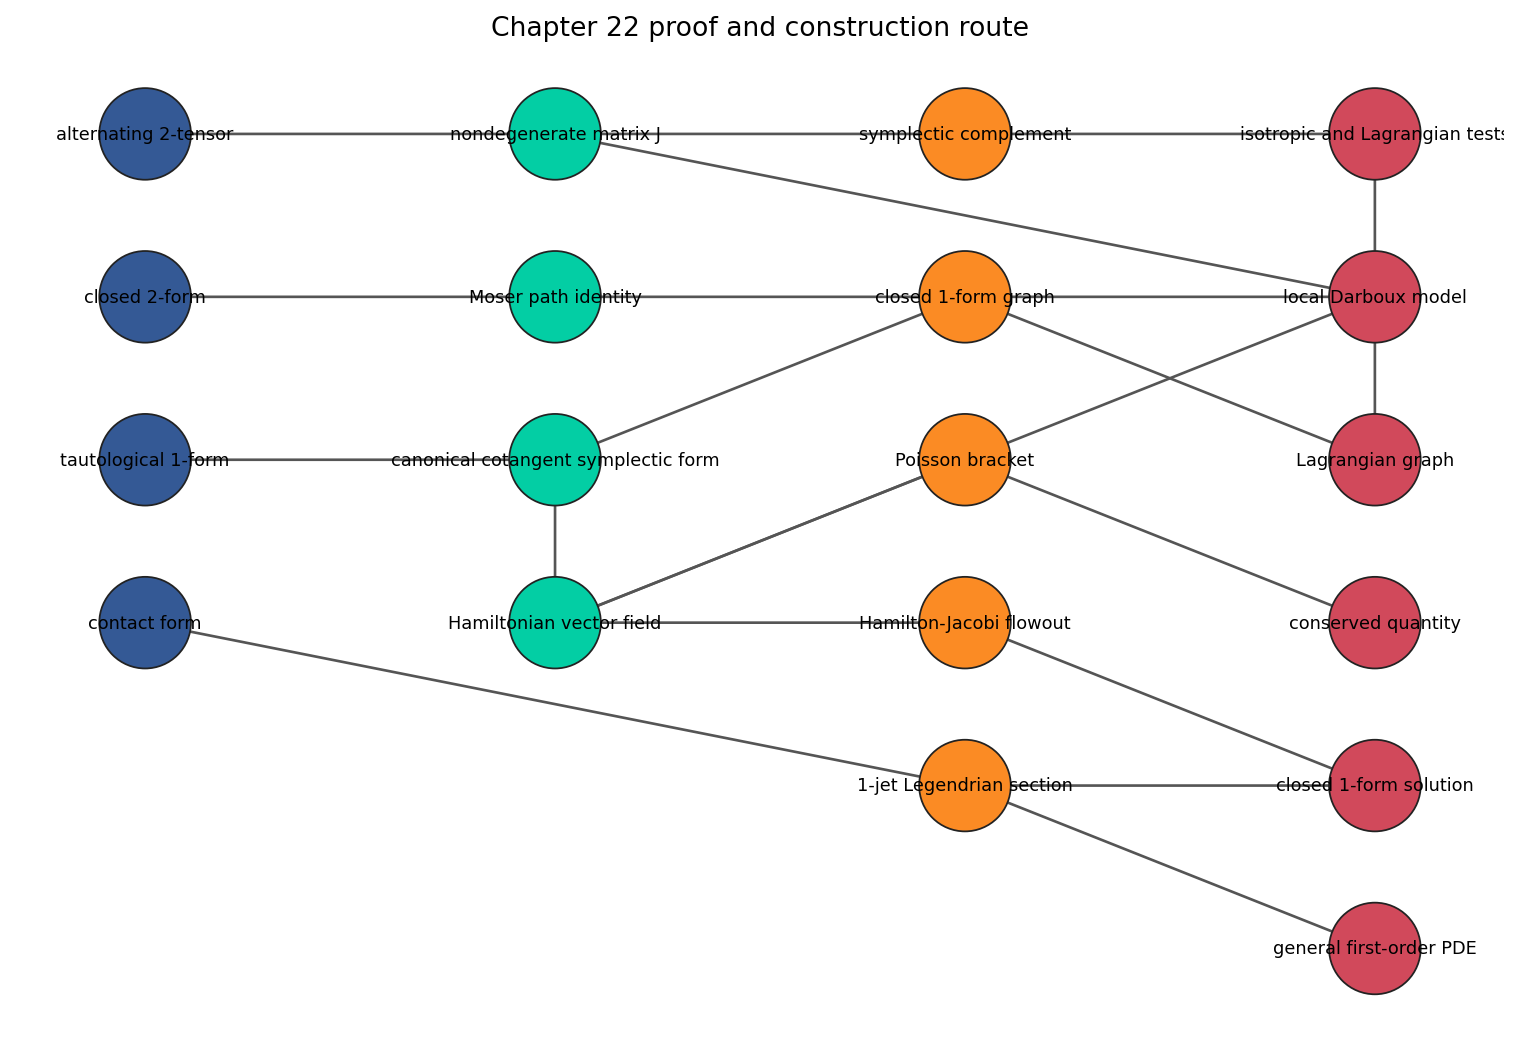

In [2]:
proof_edges = [
    ("alternating 2-tensor", "nondegenerate matrix J"),
    ("nondegenerate matrix J", "symplectic complement"),
    ("symplectic complement", "isotropic and Lagrangian tests"),
    ("nondegenerate matrix J", "local Darboux model"),
    ("closed 2-form", "Moser path identity"),
    ("Moser path identity", "local Darboux model"),
    ("local Darboux model", "Hamiltonian vector field"),
    ("tautological 1-form", "canonical cotangent symplectic form"),
    ("canonical cotangent symplectic form", "closed 1-form graph"),
    ("canonical cotangent symplectic form", "Hamiltonian vector field"),
    ("closed 1-form graph", "Lagrangian graph"),
    ("isotropic and Lagrangian tests", "Lagrangian graph"),
    ("Hamiltonian vector field", "Poisson bracket"),
    ("Poisson bracket", "conserved quantity"),
    ("Hamiltonian vector field", "Hamilton-Jacobi flowout"),
    ("Hamilton-Jacobi flowout", "closed 1-form solution"),
    ("closed 1-form solution", "1-jet Legendrian section"),
    ("contact form", "1-jet Legendrian section"),
    ("1-jet Legendrian section", "general first-order PDE"),
]
G = nx.DiGraph()
G.add_edges_from(proof_edges)
layers = {
    "alternating 2-tensor": 0,
    "closed 2-form": 0,
    "tautological 1-form": 0,
    "contact form": 0,
    "nondegenerate matrix J": 1,
    "symplectic complement": 2,
    "isotropic and Lagrangian tests": 3,
    "Moser path identity": 1,
    "local Darboux model": 3,
    "canonical cotangent symplectic form": 1,
    "closed 1-form graph": 2,
    "Lagrangian graph": 3,
    "Hamiltonian vector field": 1,
    "Poisson bracket": 2,
    "conserved quantity": 3,
    "Hamilton-Jacobi flowout": 2,
    "closed 1-form solution": 3,
    "1-jet Legendrian section": 2,
    "general first-order PDE": 3,
}
by_layer = {}
for node, layer in layers.items():
    by_layer.setdefault(layer, []).append(node)
pos = {}
for layer, nodes in by_layer.items():
    for j, node in enumerate(nodes):
        pos[node] = (layer, -j)

fig, ax = plt.subplots(figsize=(12, 8))
node_colors = [
    "#345995" if layers[n] == 0 else "#03cea4" if layers[n] == 1 else "#fb8b24" if layers[n] == 2 else "#d1495b"
    for n in G.nodes
]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.2, edge_color="#555555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1700, edgecolors="#222222", linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Chapter 22 proof and construction route")
ax.axis("off")
proof_route_path = register(save_matplotlib(fig, FIGURES / "proof-route-symplectic-to-pde.png"))
plt.close(fig)

proof_route_json = register(save_json(
    {
        "unit": UNIT_TITLE,
        "source_span_printed_pages": "564-595",
        "nodes": list(G.nodes()),
        "edges": proof_edges,
        "weakly_connected": nx.is_weakly_connected(G),
        "contains_pde_exit": nx.has_path(G, "Hamiltonian vector field", "closed 1-form solution")
        and nx.has_path(G, "contact form", "general first-order PDE"),
    },
    CHECKS / "proof-route-symplectic-to-pde.json",
))
display_artifact(proof_route_path, width=920)


## Symplectic Tensors: Nondegenerate Alternating Pairings

In a symplectic basis `(A_1, B_1, ..., A_n, B_n)`, the standard 2-form pairs each `A_i` with `B_i` and pairs no vector with itself. The matrix is skew, but it must still be invertible. This is the first point where symplectic geometry departs from Riemannian geometry: the tensor is not a positive length form; it is an oriented area-pairing.

The checks below use `n = 2`, so the ambient vector space is `R^4`.


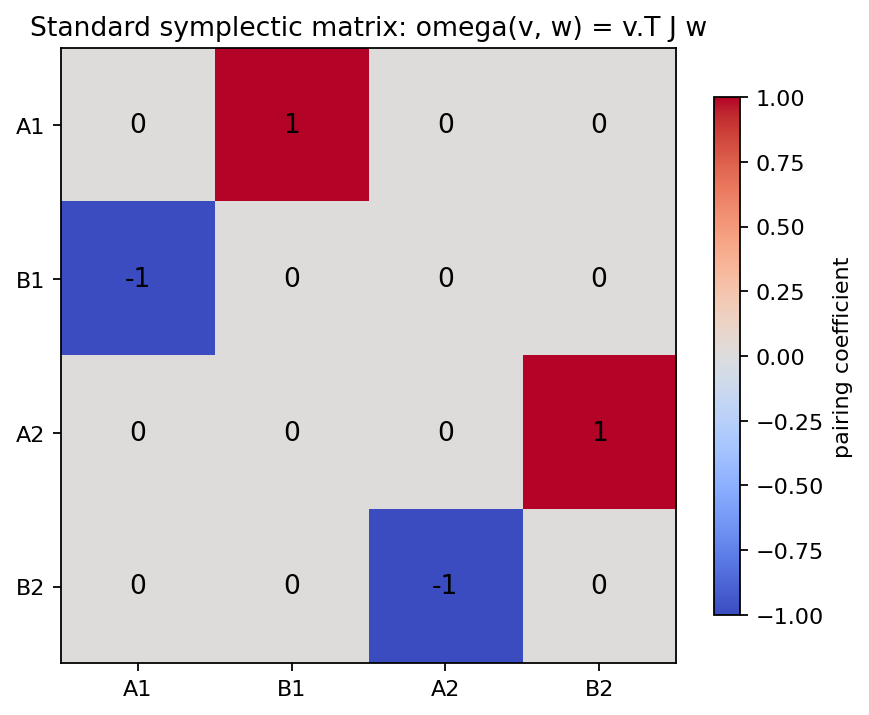

{'dimension': 4,
 'determinant': '1',
 'is_skew': True,
 'square_is_minus_identity': True,
 'top_wedge_coefficient_for_standard_form': 2,
 'nondegenerate': True}

In [3]:
def standard_symplectic_matrix(n: int) -> sp.Matrix:
    block = sp.Matrix([[0, 1], [-1, 0]])
    return sp.diag(*([block] * n))


n = 2
J = standard_symplectic_matrix(n)
labels = ["A1", "B1", "A2", "B2"]
J_np = np.array(J.tolist(), dtype=float)

fig, ax = plt.subplots(figsize=(6.2, 5.6))
im = ax.imshow(J_np, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(2 * n), labels=labels)
ax.set_yticks(range(2 * n), labels=labels)
for i in range(2 * n):
    for j in range(2 * n):
        ax.text(j, i, str(int(J_np[i, j])), ha="center", va="center", color="black", fontsize=12)
ax.set_title("Standard symplectic matrix: omega(v, w) = v.T J w")
fig.colorbar(im, ax=ax, shrink=0.75, label="pairing coefficient")
matrix_path = register(save_matplotlib(fig, FIGURES / "canonical-symplectic-matrix.png"))
plt.close(fig)

linear_checks = {
    "dimension": 2 * n,
    "determinant": str(J.det()),
    "is_skew": bool(J.T == -J),
    "square_is_minus_identity": bool(J * J == -sp.eye(2 * n)),
    "top_wedge_coefficient_for_standard_form": math.factorial(n),
    "nondegenerate": bool(J.det() != 0),
}
linear_checks_path = register(save_json(linear_checks, CHECKS / "linear-algebra-invariants.json"))
display_artifact(matrix_path, width=560)
linear_checks


## Symplectic Complements and Subspace Types

For a subspace `S` with basis matrix `B`, the symplectic complement is the nullspace of `B.T * J`: it consists of vectors `v` whose symplectic pairing with every vector in `S` is zero. The dimension formula `dim S + dim S^omega = dim V` remains true, but the intersection `S cap S^omega` can be nonzero.

The four sample subspaces below are deliberately small witnesses for the four labels used in the chapter. The classification comes from exact rank, nullspace, and containment tests rather than a picture alone.


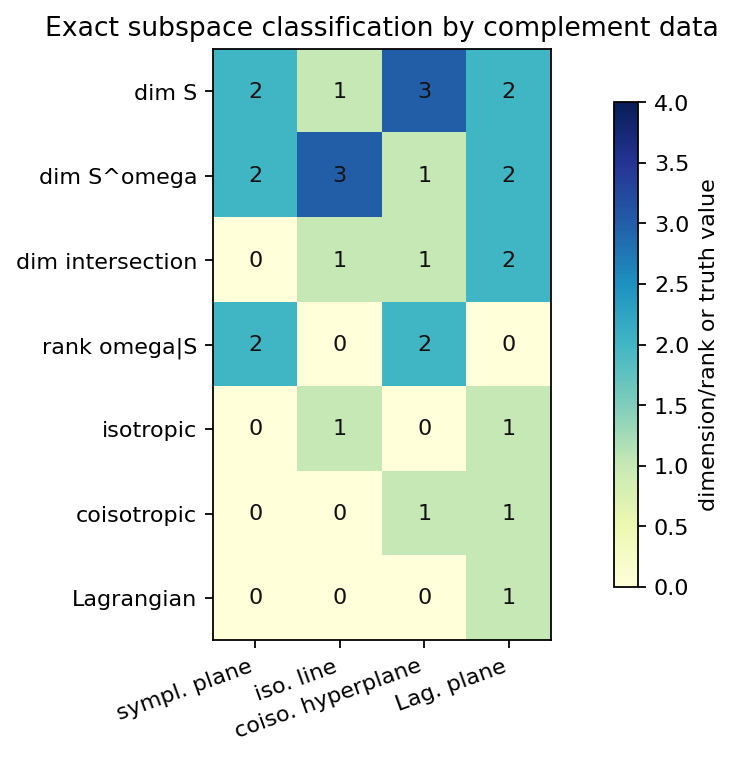

Classification table saved to `artifacts\chapter-22-symplectic-manifolds\tables\subspace-type-classification.csv`.

[{'subspace': 'symplectic plane span(A1,B1)',
  'dim_S': 2,
  'dim_complement': 2,
  'dim_sum': 4,
  'intersection_dim': 0,
  'rank_omega_restricted': 2,
  'symplectic': True,
  'isotropic': False,
  'coisotropic': False,
  'lagrangian': False},
 {'subspace': 'isotropic line span(A1)',
  'dim_S': 1,
  'dim_complement': 3,
  'dim_sum': 4,
  'intersection_dim': 1,
  'rank_omega_restricted': 0,
  'symplectic': False,
  'isotropic': True,
  'coisotropic': False,
  'lagrangian': False},
 {'subspace': 'coisotropic hyperplane span(A1,A2,B1)',
  'dim_S': 3,
  'dim_complement': 1,
  'dim_sum': 4,
  'intersection_dim': 1,
  'rank_omega_restricted': 2,
  'symplectic': False,
  'isotropic': False,
  'coisotropic': True,
  'lagrangian': False},
 {'subspace': 'Lagrangian plane span(A1,A2)',
  'dim_S': 2,
  'dim_complement': 2,
  'dim_sum': 4,
  'intersection_dim': 2,
  'rank_omega_restricted': 0,
  'symplectic': False,
  'isotropic': True,
  'coisotropic': True,
  'lagrangian': True}]

In [4]:
ambient_basis = sp.eye(4)
subspace_columns = {
    "symplectic plane span(A1,B1)": [0, 1],
    "isotropic line span(A1)": [0],
    "coisotropic hyperplane span(A1,A2,B1)": [0, 2, 1],
    "Lagrangian plane span(A1,A2)": [0, 2],
}


def basis_matrix(indices: list[int]) -> sp.Matrix:
    return sp.Matrix.hstack(*[ambient_basis[:, i] for i in indices])


def matrix_rank(M: sp.Matrix) -> int:
    return int(M.rank())


def complement_basis(B: sp.Matrix) -> sp.Matrix:
    ns = (B.T * J).nullspace()
    if not ns:
        return sp.zeros(4, 0)
    return sp.Matrix.hstack(*ns)


def combined_rank(A: sp.Matrix, B: sp.Matrix) -> int:
    if A.shape[1] == 0:
        return matrix_rank(B)
    if B.shape[1] == 0:
        return matrix_rank(A)
    return matrix_rank(A.row_join(B))


classification_rows = []
classification_checks = {}
for name, indices in subspace_columns.items():
    B = basis_matrix(indices)
    C = complement_basis(B)
    restricted = B.T * J * B
    dim_s = matrix_rank(B)
    dim_c = matrix_rank(C)
    rank_join = combined_rank(B, C)
    intersection_dim = dim_s + dim_c - rank_join
    s_in_comp = combined_rank(C, B) == dim_c
    comp_in_s = combined_rank(B, C) == dim_s
    restricted_rank = matrix_rank(restricted)
    row = {
        "subspace": name,
        "dim_S": dim_s,
        "dim_complement": dim_c,
        "dim_sum": dim_s + dim_c,
        "intersection_dim": intersection_dim,
        "rank_omega_restricted": restricted_rank,
        "symplectic": intersection_dim == 0,
        "isotropic": s_in_comp,
        "coisotropic": comp_in_s,
        "lagrangian": s_in_comp and comp_in_s and dim_s == 2,
    }
    classification_rows.append(row)
    classification_checks[name] = row

subspace_table_path = register(save_csv(classification_rows, TABLES / "subspace-type-classification.csv"))
subspace_checks = {
    "ambient_dimension": 4,
    "all_dimension_formulas_hold": all(row["dim_sum"] == 4 for row in classification_rows),
    "lagrangian_example_detected": classification_checks["Lagrangian plane span(A1,A2)"]["lagrangian"],
    "symplectic_plane_has_zero_intersection": classification_checks["symplectic plane span(A1,B1)"]["intersection_dim"] == 0,
    "rows": classification_rows,
}
subspace_checks_path = register(save_json(subspace_checks, CHECKS / "subspace-classification.json"))

metrics = np.array(
    [
        [int(row["dim_S"]) for row in classification_rows],
        [int(row["dim_complement"]) for row in classification_rows],
        [int(row["intersection_dim"]) for row in classification_rows],
        [int(row["rank_omega_restricted"]) for row in classification_rows],
        [int(row["isotropic"]) for row in classification_rows],
        [int(row["coisotropic"]) for row in classification_rows],
        [int(row["lagrangian"]) for row in classification_rows],
    ],
    dtype=float,
)
row_labels = ["dim S", "dim S^omega", "dim intersection", "rank omega|S", "isotropic", "coisotropic", "Lagrangian"]
col_labels = ["sympl. plane", "iso. line", "coiso. hyperplane", "Lag. plane"]
fig, ax = plt.subplots(figsize=(10.2, 4.8))
im = ax.imshow(metrics, cmap="YlGnBu", vmin=0, vmax=4)
ax.set_xticks(range(len(col_labels)), labels=col_labels, rotation=20, ha="right")
ax.set_yticks(range(len(row_labels)), labels=row_labels)
for i in range(metrics.shape[0]):
    for j in range(metrics.shape[1]):
        ax.text(j, i, str(int(metrics[i, j])), ha="center", va="center", color="#111111")
ax.set_title("Exact subspace classification by complement data")
fig.colorbar(im, ax=ax, shrink=0.82, label="dimension/rank or truth value")
subspace_fig_path = register(save_matplotlib(fig, FIGURES / "subspace-type-classification.png"))
plt.close(fig)

display_artifact(subspace_fig_path, width=820)
display(Markdown(f"Classification table saved to `{subspace_table_path.relative_to(BOOK_ROOT)}`."))
classification_rows


## Canonical Cotangent Form and Closed Graphs

On `T*R^2` with coordinates `(x, y, p, q)`, the tautological 1-form is `theta = p dx + q dy`, and the canonical symplectic form is `omega = -d theta = dx wedge dp + dy wedge dq`.

If a 1-form on the base is `alpha = P dx + Q dy`, its graph is `(x, y, P(x,y), Q(x,y))`. Pulling back the canonical symplectic form to that graph gives `(P_y - Q_x) dx wedge dy`, so the graph is Lagrangian exactly when `alpha` is closed. The figure projects each graph to `(x, y, p)` and uses color for `q`.


In [5]:
grid = np.linspace(-1.2, 1.2, 55)
X, Y = np.meshgrid(grid, grid)

# Closed: alpha = d(0.5*x**2 + x*y), so P_y - Q_x = 0.
P_closed = X + Y
Q_closed = X
closed_residual = 0.0

# Nonclosed: the graph still exists, but it is not Lagrangian.
P_nonclosed = -0.5 * Y
Q_nonclosed = 0.5 * X
nonclosed_residual = -1.0

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=["closed 1-form graph", "nonclosed 1-form graph"],
)
fig.add_trace(
    go.Surface(x=X, y=Y, z=P_closed, surfacecolor=Q_closed, colorscale="Viridis", showscale=False),
    row=1,
    col=1,
)
fig.add_trace(
    go.Surface(x=X, y=Y, z=P_nonclosed, surfacecolor=Q_nonclosed, colorscale="RdBu", showscale=False),
    row=1,
    col=2,
)
fig.update_layout(
    title="Graphs of 1-forms in T*R^2: color records q",
    height=560,
    width=1000,
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="p"),
    scene2=dict(xaxis_title="x", yaxis_title="y", zaxis_title="p"),
    margin=dict(l=0, r=0, t=70, b=0),
)
cotangent_html_path = save_plotly_standalone(fig, HTML / "cotangent-closed-graph-lagrangian.html")

x, y = sp.symbols("x y", real=True)
P1, Q1 = x + y, x
P2, Q2 = -sp.Rational(1, 2) * y, sp.Rational(1, 2) * x
pullback_closed = sp.simplify(sp.diff(P1, y) - sp.diff(Q1, x))
pullback_nonclosed = sp.simplify(sp.diff(P2, y) - sp.diff(Q2, x))
cotangent_checks = {
    "canonical_form": "omega = dx wedge dp + dy wedge dq",
    "closed_graph_pullback_coefficient": str(pullback_closed),
    "nonclosed_graph_pullback_coefficient": str(pullback_nonclosed),
    "closed_graph_is_lagrangian": bool(pullback_closed == 0),
    "nonclosed_graph_detected": bool(pullback_nonclosed != 0),
}
cotangent_checks_path = register(save_json(cotangent_checks, CHECKS / "cotangent-lagrangian-graph.json"))
display_artifact(cotangent_html_path, width=900, height=560)
cotangent_checks


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'canonical_form': 'omega = dx wedge dp + dy wedge dq',
 'closed_graph_pullback_coefficient': '0',
 'nonclosed_graph_pullback_coefficient': '-1',
 'closed_graph_is_lagrangian': True,
 'nonclosed_graph_detected': True}

## Darboux via a Moser Correction Field

Darboux's theorem says that every symplectic form has standard coordinates near each point. The proof in the source uses Moser's idea: connect the given form to the standard one by a path `omega_t`, then choose a time-dependent vector field whose flow makes the pullback constant in `t`.

The local model below starts with

`omega_0 = dx wedge dy`, `omega_1 = (1 + eps*(x^2+y^2)) dx wedge dy`.

The correction field is radial and inward when `eps > 0`. The symbolic check verifies the proof identity

`d(i_{V_t} omega_t) + d/dt omega_t = 0`.


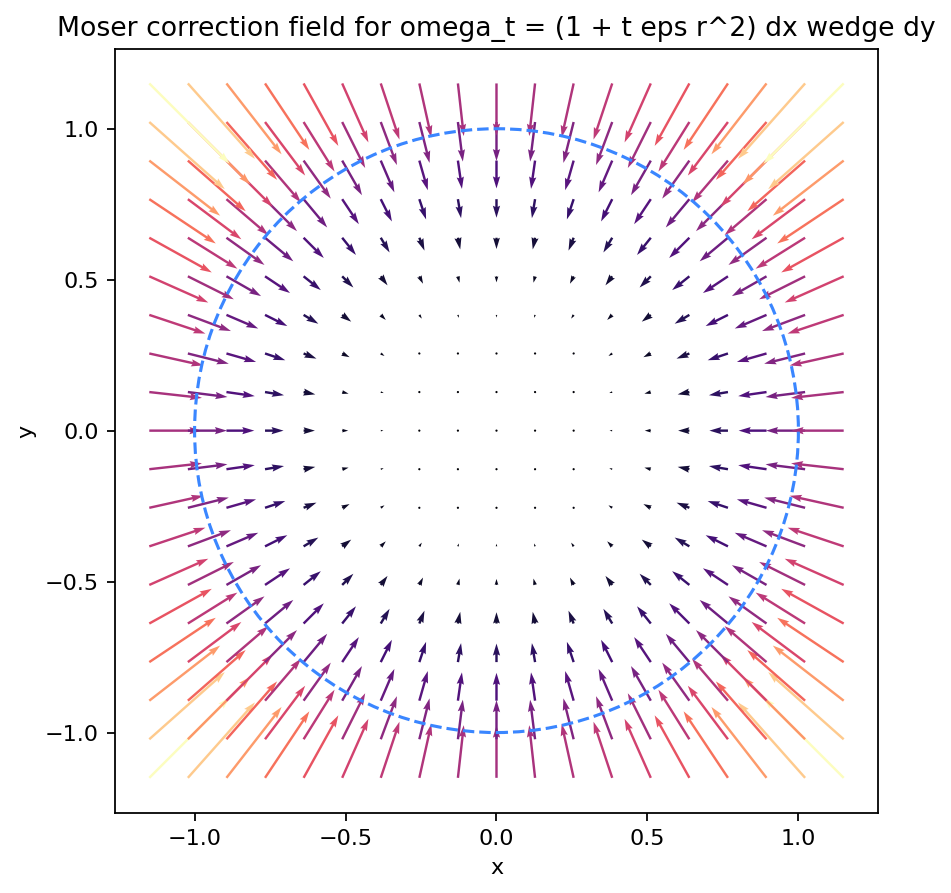

{'interior_product_dx_coefficient': 'eps*y*(x**2 + y**2)/4',
 'interior_product_dy_coefficient': '-eps*x*(x**2 + y**2)/4',
 'chosen_alpha_dx': 'eps*y*(x**2 + y**2)/4',
 'chosen_alpha_dy': '-eps*x*(x**2 + y**2)/4',
 'd_alpha_plus_dt_omega': '0',
 'moser_identity_holds': True,
 'sample_field_max_speed': 0.3758949609701465}

In [6]:
eps, t = sp.symbols("eps t", positive=True)
r2 = x**2 + y**2
f_t = 1 + t * eps * r2
alpha_dx = eps * r2 * y / 4
alpha_dy = -eps * r2 * x / 4
Vx = -eps * r2 * x / (4 * f_t)
Vy = -eps * r2 * y / (4 * f_t)

# For omega_t = f_t dx wedge dy, i_V omega_t = f_t*(Vx dy - Vy dx).
interior_dx = sp.simplify(-f_t * Vy)
interior_dy = sp.simplify(f_t * Vx)
d_alpha_coeff = sp.simplify(sp.diff(alpha_dy, x) - sp.diff(alpha_dx, y))
path_derivative_coeff = sp.diff(f_t, t)
moser_residual = sp.simplify(d_alpha_coeff + path_derivative_coeff)

mesh = np.linspace(-1.15, 1.15, 19)
Xm, Ym = np.meshgrid(mesh, mesh)
eps_value = 0.65
t_value = 0.5
R2m = Xm**2 + Ym**2
factor = -eps_value * R2m / (4 * (1 + t_value * eps_value * R2m))
Um = factor * Xm
Vm = factor * Ym

fig, ax = plt.subplots(figsize=(6.8, 6.2))
speed = np.sqrt(Um**2 + Vm**2)
ax.quiver(Xm, Ym, Um, Vm, speed, cmap="magma", angles="xy", scale_units="xy", scale=1.0)
circle = plt.Circle((0, 0), 1.0, edgecolor="#3a86ff", facecolor="none", linestyle="--", linewidth=1.4)
ax.add_patch(circle)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Moser correction field for omega_t = (1 + t eps r^2) dx wedge dy")
moser_fig_path = register(save_matplotlib(fig, FIGURES / "moser-darboux-radial-field.png"))
plt.close(fig)

moser_checks = {
    "interior_product_dx_coefficient": str(interior_dx),
    "interior_product_dy_coefficient": str(interior_dy),
    "chosen_alpha_dx": str(alpha_dx),
    "chosen_alpha_dy": str(alpha_dy),
    "d_alpha_plus_dt_omega": str(moser_residual),
    "moser_identity_holds": bool(moser_residual == 0),
    "sample_field_max_speed": float(speed.max()),
}
moser_checks_path = register(save_json(moser_checks, CHECKS / "moser-darboux-residual.json"))
display_artifact(moser_fig_path, width=620)
moser_checks


## Hamiltonian Vector Fields, Poisson Brackets, and Conservation

For `omega = dq wedge dp`, the Hamiltonian vector field is

`X_H = H_p d/dq - H_q d/dp`.

The oscillator `H = (p^2 + q^2)/2` makes the chapter's two basic facts visible: the Hamiltonian is constant along its own flow, and the vector field is tangent to the level curves. The four-dimensional symbolic check then verifies a Noether-style conserved quantity: angular momentum Poisson-commutes with the isotropic oscillator Hamiltonian.


In [7]:
time = np.linspace(0, 2 * np.pi, 360)
fig = go.Figure()
energy_drifts = []
for radius, phase, color in [(0.55, 0.0, "#1f77b4"), (1.0, 0.45, "#ff7f0e"), (1.45, 1.0, "#2ca02c")]:
    q_vals = radius * np.cos(time + phase)
    p_vals = -radius * np.sin(time + phase)
    energy = 0.5 * (q_vals**2 + p_vals**2)
    energy_drifts.append(float(np.max(np.abs(energy - energy[0]))))
    fig.add_trace(
        go.Scatter(
            x=q_vals,
            y=p_vals,
            mode="lines",
            name=f"H={energy[0]:.3f}",
            line=dict(width=3, color=color),
        )
    )
fig.update_layout(
    title="Hamiltonian oscillator: trajectories stay on energy levels",
    xaxis_title="q",
    yaxis_title="p",
    width=720,
    height=620,
    yaxis_scaleanchor="x",
    margin=dict(l=40, r=20, t=60, b=40),
)
hamiltonian_html_path = save_plotly_standalone(fig, HTML / "hamiltonian-oscillator-flow.html")

q, p, q1, p1, q2, p2 = sp.symbols("q p q1 p1 q2 p2", real=True)
H_osc = sp.Rational(1, 2) * (p**2 + q**2)
XH_q = sp.diff(H_osc, p)
XH_p = -sp.diff(H_osc, q)
energy_derivative = sp.simplify(sp.diff(H_osc, q) * XH_q + sp.diff(H_osc, p) * XH_p)


def poisson_2d(f, g, pairs):
    total = 0
    for qi, pi in pairs:
        total += sp.diff(f, qi) * sp.diff(g, pi) - sp.diff(f, pi) * sp.diff(g, qi)
    return sp.simplify(total)


H4 = sp.Rational(1, 2) * (p1**2 + p2**2 + q1**2 + q2**2)
L = q1 * p2 - q2 * p1
poisson_L_H = poisson_2d(L, H4, [(q1, p1), (q2, p2)])
poisson_q_p = poisson_2d(q, p, [(q, p)])
hamiltonian_checks = {
    "oscillator_vector_field": {"dq_dt": str(XH_q), "dp_dt": str(XH_p)},
    "dH_along_XH": str(energy_derivative),
    "max_numeric_energy_drift": max(energy_drifts),
    "poisson_q_p": str(poisson_q_p),
    "angular_momentum_L": str(L),
    "poisson_L_H": str(poisson_L_H),
    "energy_conserved": bool(energy_derivative == 0 and max(energy_drifts) < 1e-12),
    "angular_momentum_commutes_with_H": bool(poisson_L_H == 0),
}
hamiltonian_checks_path = register(save_json(hamiltonian_checks, CHECKS / "poisson-conservation.json"))
display_artifact(hamiltonian_html_path, width=760, height=620)
hamiltonian_checks


{'oscillator_vector_field': {'dq_dt': 'p', 'dp_dt': '-q'},
 'dH_along_XH': '0',
 'max_numeric_energy_drift': 4.440892098500626e-16,
 'poisson_q_p': '1',
 'angular_momentum_L': '-p1*q2 + p2*q1',
 'poisson_L_H': '0',
 'energy_conserved': True,
 'angular_momentum_commutes_with_H': True}

## Hamilton-Jacobi Flowouts and Contact/Jet Geometry

A Hamilton-Jacobi equation `F(x, du_x) = 0` can be attacked by first constructing a Lagrangian submanifold in `T*M`: choose an initial covector section, flow it by the Hamiltonian vector field of `F`, then read off a closed 1-form and integrate locally.

For a concrete check, use the local solution

`u(x,y) = y^2 / (1 - 4x)`

on the side of the line where the denominator is positive. Its first derivatives satisfy `u_x - (u_y)^2 = 0`, and its 1-jet section `(x, y, z, p, q) = (x, y, u, u_x, u_y)` pulls back the canonical contact form `eta = dz - p dx - q dy` to zero. The plotted curves are characteristic traces on the solution surface.


In [8]:
Xg, Yg = np.meshgrid(np.linspace(-0.16, 0.19, 80), np.linspace(-0.85, 0.85, 90))
Ug = Yg**2 / (1 - 4 * Xg)
Pg = 4 * Yg**2 / (1 - 4 * Xg) ** 2
Qg = 2 * Yg / (1 - 4 * Xg)
residual_grid = Pg - Qg**2

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=Xg,
        y=Yg,
        z=Ug,
        surfacecolor=residual_grid,
        colorscale="RdBu",
        cmin=-1e-12,
        cmax=1e-12,
        name="solution surface",
        colorbar=dict(title="PDE residual"),
        opacity=0.9,
    )
)
for s in np.linspace(-0.7, 0.7, 7):
    tt = np.linspace(0, 0.19, 120)
    yy = s * (1 - 4 * tt)
    zz = s**2 * (1 - 4 * tt)
    fig.add_trace(
        go.Scatter3d(
            x=tt,
            y=yy,
            z=zz,
            mode="lines",
            line=dict(color="#111111", width=5),
            showlegend=False,
        )
    )
fig.update_layout(
    title="Hamilton-Jacobi flowout projected to the solution graph z = u(x,y)",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    width=860,
    height=660,
    margin=dict(l=0, r=0, t=60, b=0),
)
jet_html_path = save_plotly_standalone(fig, HTML / "jet-pde-flowout.html")

u_expr = y**2 / (1 - 4 * x)
p_expr = sp.diff(u_expr, x)
q_expr = sp.diff(u_expr, y)
pde_residual = sp.simplify(p_expr - q_expr**2)
contact_dx_residual = sp.simplify(sp.diff(u_expr, x) - p_expr)
contact_dy_residual = sp.simplify(sp.diff(u_expr, y) - q_expr)
initial_residual = sp.simplify(u_expr.subs(x, 0) - y**2)
jet_checks = {
    "u": str(u_expr),
    "p_equals_u_x": str(p_expr),
    "q_equals_u_y": str(q_expr),
    "hamilton_jacobi_residual": str(pde_residual),
    "contact_pullback_dx_residual": str(contact_dx_residual),
    "contact_pullback_dy_residual": str(contact_dy_residual),
    "initial_condition_residual_at_x0": str(initial_residual),
    "max_numeric_pde_residual": float(np.max(np.abs(residual_grid))),
    "legendrian_and_pde_checks_pass": bool(
        pde_residual == 0
        and contact_dx_residual == 0
        and contact_dy_residual == 0
        and initial_residual == 0
        and float(np.max(np.abs(residual_grid))) < 1e-10
    ),
}
jet_checks_path = register(save_json(jet_checks, CHECKS / "jet-pde-contact-residual.json"))
display_artifact(jet_html_path, width=860, height=660)
jet_checks


{'u': 'y**2/(1 - 4*x)',
 'p_equals_u_x': '4*y**2/(1 - 4*x)**2',
 'q_equals_u_y': '2*y/(1 - 4*x)',
 'hamilton_jacobi_residual': '0',
 'contact_pullback_dx_residual': '0',
 'contact_pullback_dy_residual': '0',
 'initial_condition_residual_at_x0': '0',
 'max_numeric_pde_residual': 1.4210854715202004e-14,
 'legendrian_and_pde_checks_pass': True}

## Applied Lab: Break One Hypothesis

Use the cells above as a small experimental harness.

- Replace the Lagrangian graph's closed 1-form by a nonclosed one and watch the pullback coefficient become nonzero.
- Change the Moser model to `1 - eps*(x^2+y^2)` and locate where nondegeneracy can fail.
- Replace the oscillator Hamiltonian by an anisotropic one and recompute the Poisson bracket with angular momentum.
- In the Hamilton-Jacobi model, move toward `x = 1/4`; the local graph stops being a good single-valued solution there.

These are not separate facts. Each perturbation targets a chapter hypothesis: nondegeneracy, closedness, local solvability, or conservation.


## Final Sanity Checks

The final cell checks that the notebook's claims have executable witnesses:

- all generated artifacts exist and are nonempty;
- `J` is skew and invertible;
- the complement dimension formula holds for every sample subspace;
- the closed 1-form graph is Lagrangian and the nonclosed graph is rejected;
- the Moser residual vanishes symbolically;
- the Hamiltonian and angular momentum conservation checks pass;
- the 1-jet/PDE surface is both Legendrian and a solution of the Hamilton-Jacobi equation.


In [9]:
final_sanity = {
    "proof_route_connected": nx.is_weakly_connected(G),
    "linear_non_degenerate": linear_checks["nondegenerate"] and linear_checks["is_skew"],
    "subspace_dimension_formula": subspace_checks["all_dimension_formulas_hold"],
    "lagrangian_graph_detected": cotangent_checks["closed_graph_is_lagrangian"]
    and cotangent_checks["nonclosed_graph_detected"],
    "moser_identity": moser_checks["moser_identity_holds"],
    "hamiltonian_conservation": hamiltonian_checks["energy_conserved"]
    and hamiltonian_checks["angular_momentum_commutes_with_H"],
    "jet_contact_and_pde": jet_checks["legendrian_and_pde_checks_pass"],
}
for name, passed in final_sanity.items():
    assert passed, f"failed final check: {name}"

summary_path = register(save_json(
    {
        "unit": UNIT_TITLE,
        "source_span_printed_pages": "564-595",
        "artifact_count": len(generated_artifacts),
        "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in generated_artifacts],
        "checks": final_sanity,
    },
    CHECKS / "final-sanity-summary.json",
))
assert_artifacts(generated_artifacts, min_bytes=64)
display(Markdown(f"Final sanity passed with `{len(generated_artifacts)}` artifacts."))
display(Markdown(f"Summary saved to `{summary_path.relative_to(BOOK_ROOT)}`."))


Final sanity passed with `17` artifacts.

Summary saved to `artifacts\chapter-22-symplectic-manifolds\checks\final-sanity-summary.json`.

## Takeaways

- A symplectic form is an invertible alternating area-pairing; its matrix model is skew but nondegenerate.
- Symplectic complements classify subspaces by containment, not by Euclidean perpendicularity.
- The cotangent bundle carries a canonical symplectic form, and closed 1-form graphs are exactly the Lagrangian graphs in this local model.
- Darboux's theorem is powered by a deformation identity: choose `V_t` so the changing form has zero pullback derivative along the flow.
- Hamiltonian vector fields preserve their Hamiltonians; Poisson brackets measure whether one function changes along another function's flow.
- Contact geometry on 1-jet bundles is the odd-dimensional partner that packages general first-order PDEs through Legendrian sections and flowouts.
